In [24]:
# imports

import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np
from scipy.signal import savgol_filter
import scipy.stats as stats
import itertools


# Configuração do diretório
data_dir = (
    r"C:\Users\gabri\Documents\PROJETOS\POLI\PY\Lab Física\Fotoelétrico\attachments"
)
sem_file = os.path.join(data_dir, "sem.csv")

# Carregar dados de ruído (fundo)
df_sem = pd.read_csv(sem_file, sep=";", decimal=",")

In [25]:
# --- Configurações e Constantes ---

# Constantes Físicas
h = 4.135667696e-15  # eV.s (Constante de Planck)
c = 299792458  # m/s (Velocidade da luz)

# Frequências (x 10^14 Hz)
frequencias = {
    "Vermelho": 4.875,
    "Amarelo": 5.187,
    "Verde": 5.490,
    "Azul": 6.879,
    "Violeta": 7.409,
    "Ultra-Violeta": 8.213,
}

# Configurações de Cores e Gráficos
# Ordem: Amarelo, Verde, Azul, Violeta, Ultra-Violeta, Vermelho
colors_info = [
    {"name": "Vermelho", "prefix": "ver", "letter": "(f)", "xlim": (-1.5, 1.0)},
    {"name": "Amarelo", "prefix": "amar", "letter": "(a)", "xlim": (-1.5, 0.5)},
    {"name": "Verde", "prefix": "verde", "letter": "(b)", "xlim": (-2.5, 0.5)},
    {"name": "Azul", "prefix": "azul", "letter": "(c)", "xlim": (-3.0, 0.5)},
    {"name": "Violeta", "prefix": "vio", "letter": "(d)", "xlim": (-3.5, 0.5)},
    {"name": "Ultra-Violeta", "prefix": "UV", "letter": "(e)", "xlim": (-4.0, 0.5)},
]

# Intensidades
intensities = [100, 80, 60, 40, 20]

# Estilo global
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.axisbelow"] = True

Processando dados e calculando V0 por múltiplos métodos...

--- Exemplo Visual para Ultra-Violeta (Método 4) ---


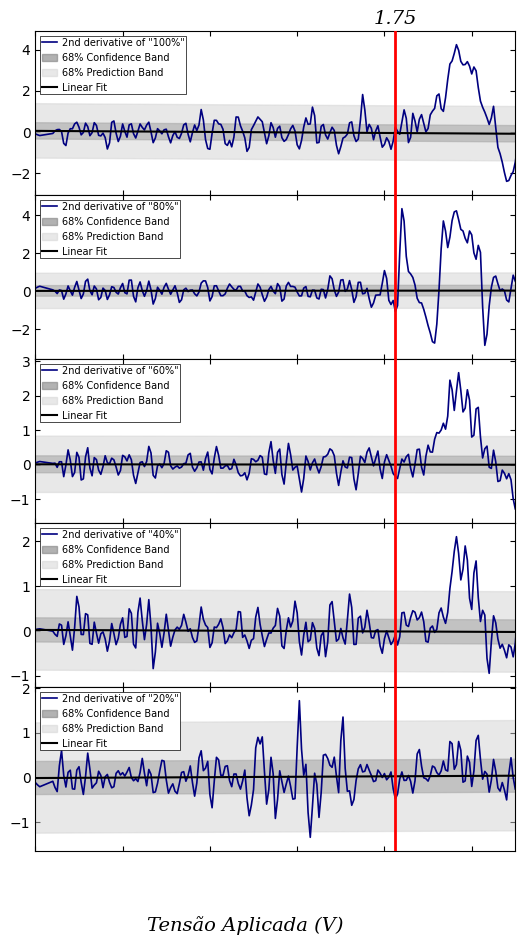


=== Comparação dos Métodos para Determinação de V0 (Volts) ===


,M1 (Zero),M2 (Tan),M3 (Inter),M4 (2Der),Esperado,Erro_M1_%,Erro_M2_%,Erro_M3_%,Erro_M4_%
Cor,,,,,,,,,
Vermelho,3.4495,0.2329,0.2662,1.1600,0.6500,430.70%,-64.16%,-59.05%,78.46%
Amarelo,2.8040,0.2721,0.2331,1.2500,0.7800,259.49%,-65.11%,-70.12%,60.26%
Verde,2.7893,0.2915,0.2783,1.3300,0.9100,206.51%,-67.96%,-69.42%,46.15%
Azul,1.9218,0.4547,0.4657,1.7200,1.4800,29.85%,-69.28%,-68.53%,16.22%
Violeta,2.4119,0.4311,0.5020,1.7600,1.7000,41.88%,-74.64%,-70.47%,3.53%
Ultra-Violeta,1.0548,0.3109,0.4266,1.7500,2.0300,-48.04%,-84.69%,-78.98%,-13.79%



Consistência entre métodos (Desvio Padrão):
Cor
Vermelho         1.510571
Amarelo          1.205079
Verde            1.185250
Azul             0.789896
Violeta          0.972511
Ultra-Violeta    0.662513
Name: Std_Metodos, dtype: float64


In [26]:
# --- Funções para os 4 Métodos de determinação de V0 ---

# Helper Constants
SAVGOL_WINDOW = 15
SAVGOL_POLY = 3
SCALE = 1e10
MIN_DATA_POINTS = 20
V0_RANGE = (-5, 2)
SLOPE_THRESHOLD = 1e-5


def method_1_zero_crossing(v, i_vals):
    """Método 1: V0 é o cruzamento com zero da corrente (sem ajuste de offset)."""
    i_s = i_vals * SCALE
    # Encontrar mudanças de sinal
    signs = np.sign(i_s)
    sign_changes = ((np.roll(signs, 1) - signs) != 0).astype(int)
    sign_changes[0] = 0
    indices = np.where(sign_changes == 1)[0]

    best_v0 = np.nan
    min_dist = float("inf")

    for idx in indices:
        if idx == 0 or idx >= len(v):
            continue
        y0, y1 = i_s[idx - 1], i_s[idx]
        x0, x1 = v[idx - 1], v[idx]

        if abs(y1 - y0) < 1e-15:
            continue

        # Interpolação linear para encontrar o zero exato
        v_cross = x0 - y0 * (x1 - x0) / (y1 - y0)

        # Critério: O cruzamento mais próximo de zero no range válido
        if abs(v_cross) < min_dist and -5 < v_cross < 2:
            min_dist = abs(v_cross)
            best_v0 = v_cross

    return best_v0


def method_2_tangents(v, i_vals, window_size=10, bg_offset=10, bg_width=40):
    """Método 2: Intersecção da reta tangente da subida com a reta de ruído (fundo)."""
    if len(v) < MIN_DATA_POINTS:
        return np.nan

    i_s = i_vals * SCALE
    # Suavizar e encontrar máxima derivada (ponto de inflexão da subida)
    i_smooth = savgol_filter(i_s, 15, 3)
    di = np.gradient(i_smooth)
    max_deriv_idx = np.argmax(di)

    # 1. Reta da Subida (Tangente)
    s_r = max(0, max_deriv_idx - window_size)
    e_r = min(len(v), max_deriv_idx + window_size)
    if e_r - s_r < 3:
        return np.nan
    res_rise = stats.linregress(v[s_r:e_r], i_smooth[s_r:e_r])

    # 2. Reta de Fundo (Ruído)
    # Pega região à esquerda da subida
    e_b = max(5, s_r - bg_offset)
    s_b = max(0, e_b - bg_width)
    if e_b - s_b < 5:
        return np.nan
    res_bg = stats.linregress(v[s_b:e_b], i_smooth[s_b:e_b])

    # Evitar div por zero (retas paralelas)
    if abs(res_rise.slope - res_bg.slope) < 1e-5:
        return np.nan

    # Ponto de intersecção
    intersection = (res_bg.intercept - res_rise.intercept) / (
        res_rise.slope - res_bg.slope
    )

    if not (-5 < intersection < 2):
        return np.nan
    return intersection


def method_3_intersection_curves(curves_list, min_curves=2, window_half=8):
    """Método 3: Intersecção das tangentes de curvas de diferentes intensidades."""
    if len(curves_list) < min_curves:
        return np.nan

    lines = []
    # Coletar retas de subida para cada curva (intensidade)
    for v, i_vals in curves_list:
        if len(v) < MIN_DATA_POINTS:
            continue

        i_s = i_vals * SCALE
        i_smooth = savgol_filter(i_s, min(15, len(i_s) // 3 if len(i_s) > 9 else 3), 3)
        di = np.gradient(i_smooth)
        max_idx = np.argmax(di)

        # Janela ao redor da máxima derivada
        w = min(window_half, max_idx, len(v) - max_idx - 1)
        s, e = max(0, max_idx - w), min(len(v), max_idx + w)

        if e - s >= 5:
            res = stats.linregress(v[s:e], i_smooth[s:e])
            if abs(res.slope) > 1e-5:
                lines.append((res.slope, res.intercept))

    if len(lines) < 2:
        return np.nan

    # Encontrar intersecções par a par
    v0_candidates = []
    for (a1, b1), (a2, b2) in itertools.combinations(lines, 2):
        if abs(a1 - a2) > 1e-2:  # Deve haver alguma diferença de inclinação
            v_int = (b2 - b1) / (a1 - a2)
            if -5 < v_int < 1:
                v0_candidates.append(v_int)

    # Retornar a mediana das intersecções
    return np.median(v0_candidates) if v0_candidates else np.nan


def method_4_statistical_onset(
    v, i_vals, noise_region=(-9, -3), confidence_sigma=3.0, min_noise_points=10
):
    """Método 4: V0 (Onset Estatístico) via 2ª Derivada e banda de ruído."""
    if len(v) < 50:
        return np.nan

    window_size = min(21, len(i_vals) // 5)
    if window_size < 5:
        return np.nan
    if window_size % 2 == 0:
        window_size += 1

    i_s = i_vals * SCALE
    i_smooth = savgol_filter(i_s, window_size, 3)
    di = np.gradient(i_smooth, v)
    d2i = np.gradient(di, v)

    # Validar região de ruído
    mask_noise = (v >= noise_region[0]) & (v <= noise_region[1])
    if np.sum(mask_noise) < min_noise_points:
        return np.nan

    v_noise, d2i_noise = v[mask_noise], d2i[mask_noise]

    try:
        # Regressão linear no ruído da 2ª derivada
        res = stats.linregress(v_noise, d2i_noise)
        pred_noise = res.intercept + res.slope * v_noise
        residuals = d2i_noise - pred_noise

        # Remover outliers do próprio ruído (para ter um sigma robusto)
        Q1, Q3 = np.percentile(residuals, [25, 75])
        IQR = Q3 - Q1
        mask_clean = (residuals >= Q1 - 1.5 * IQR) & (residuals <= Q3 + 1.5 * IQR)

        if np.sum(mask_clean) < min_noise_points // 2:
            return np.nan

        std_noise = np.std(residuals[mask_clean])

        # Busca pelo ponto que sai da banda
        idx_search = np.where(v > noise_region[1])[0]
        for idx in idx_search:
            val_pred = res.intercept + res.slope * v[idx]
            val_real = d2i[idx]

            # Checa se violou a banda de confiança
            if np.abs(val_real - val_pred) > confidence_sigma * std_noise:
                return v[idx]

    except Exception:
        return np.nan

    return np.nan


def plot_stacked_analysis(curves_list, cor_name, noise_region=(-9, -3), sigma_mult=3.0):
    """Gera visualização detalhada do Method 4 (Origin Style)."""
    n = len(curves_list)
    fig, axes = plt.subplots(
        n, 1, figsize=(6, 2 * n), sharex=True
    )  # Slightly narrower to match aspect ratio
    if n == 1:
        axes = [axes]
    plt.subplots_adjust(hspace=0, left=0.15, right=0.95, top=0.92, bottom=0.1)

    v0_vals = []

    # Pre-calculation to find mean V0 first, if possible, or we calculate iteratively
    # For visual consistency with the image (vertical red line across all), we need a single V0 or mean
    # The image shows a single line at 1.48. Let's calculate the mean of detected V0s first.
    temp_v0s = []
    for _, (v, i, _) in enumerate(curves_list):
        v0 = method_4_statistical_onset(v, i, noise_region, sigma_mult)
        if not np.isnan(v0):
            temp_v0s.append(v0)

    global_mean_v0 = np.mean(temp_v0s) if temp_v0s else np.nan

    # Common Font settings
    font_params = {"fontfamily": "serif", "fontsize": 10, "style": "italic"}

    for i_ax, (ax, (v, i, lbl)) in enumerate(zip(axes, curves_list)):
        # Re-run logic for plotting
        i_s = i * SCALE
        win = max(15, min(21, len(i) // 5)) | 1
        # Calculate 2nd Derivative
        d2i = np.gradient(np.gradient(savgol_filter(i_s, win, 3), v), v)

        mask_noise = (v >= noise_region[0]) & (v <= noise_region[1])

        # Plot basics
        ax.plot(v, d2i, color="navy", lw=1.2, label=f'2nd derivative of "{lbl}"')

        if np.sum(mask_noise) > 5:
            # Stats on noise
            res = stats.linregress(v[mask_noise], d2i[mask_noise])
            y_pred_noise = res.intercept + res.slope * v[mask_noise]

            # Calculate residual std dev (RMSE)
            residuals = d2i[mask_noise] - y_pred_noise
            # Degrees of freedom for error (n - 2 parameters)
            n_noise = len(v[mask_noise])
            syx = np.sqrt(np.sum(residuals**2) / (n_noise - 2))

            # Linear Fit Line (extrapolated)
            x_range = np.array([v.min(), v.max()])
            y_trend = res.intercept + res.slope * x_range

            # Prediction bands (approximate for visualization: +/- sigma_mult * std_dev)
            # The image shows two bands. Let's create:
            # 1. Prediction Band (Wider, Lighter) - roughly where points should fall
            # 2. Confidence Band (Narrower, Darker) - where the MEAN line is

            # Using simple constant width approximation for visual similarity to image
            pred_interval = sigma_mult * np.std(residuals)
            conf_interval = (
                pred_interval * 0.3
            )  # Arbitrary factor for "Confidence Band" visual

            # Inner Band (Darker Gray - "Confidence Band")
            ax.fill_between(
                x_range,
                y_trend - conf_interval,
                y_trend + conf_interval,
                color="#808080",
                alpha=0.6,
                label=f"68% Confidence Band",
            )

            # Outer Band (Lighter Gray - "Prediction Band")
            ax.fill_between(
                x_range,
                y_trend - pred_interval,
                y_trend + pred_interval,
                color="#D3D3D3",
                alpha=0.5,
                label=f"68% Prediction Band",
            )

            ax.plot(x_range, y_trend, "k-", lw=1.5, label=f"Linear Fit")

        # Formatting ticks to face inwards (Scientific style)
        ax.tick_params(axis="both", direction="in", top=True, right=True, labelsize=10)

        # Legend (Custom box top-left)
        # Creating a custom legend text box to mimic the image
        # Note: True matplotlib legends can be complex to stack exactly like the image in subplots loop.
        # We will use the built-in legend with specific formatting.
        leg = ax.legend(
            loc="upper left",
            fontsize=7,
            frameon=True,
            fancybox=False,
            edgecolor="black",
            framealpha=1.0,
            handlelength=1.5,
            handletextpad=0.5,
            borderpad=0.2,
        )
        leg.get_frame().set_linewidth(0.5)

        # Set specific Y limits based on data range in the view area
        ax.set_xlim(-10, 1)

        # Adjust Y limits tightly around the visible data
        mask_view = (v >= -10) & (v <= 1)
        if np.any(mask_view):
            y_vis = d2i[mask_view]
            ymin, ymax = y_vis.min(), y_vis.max()
            margin = (ymax - ymin) * 0.1
            ax.set_ylim(ymin - margin, ymax + margin)

        # Remove x labels for all but bottom
        if i_ax < n - 1:
            ax.set_xticklabels([])

    # Vertical Line (Global Mean V0)
    if not np.isnan(global_mean_v0):
        # Draw line across all subplots
        for ax in axes:
            ax.axvline(global_mean_v0, color="red", ls="-", lw=2, zorder=10)

        # Add value text on top of the first subplot
        trans = axes[0].get_xaxis_transform()  # x in data coords, y in axes coords
        axes[0].text(
            global_mean_v0,
            1.02,
            f"{abs(global_mean_v0):.2f}",
            transform=trans,
            ha="center",
            va="bottom",
            fontsize=14,
            fontstyle="italic",
            family="serif",
        )

    # Global Axis Labels
    fig.text(
        0.5,
        0.02,
        "Tensão Aplicada (V)",
        ha="center",
        fontsize=14,
        fontstyle="italic",
        family="serif",
    )
    # Y label is tricky with subplots, omitting for cleaner look or adding if needed

    plt.show()


# --- Execução e Comparação dos 4 Métodos ---
SIGMA_INST = 0.005  # Incerteza instrumental
results_comparison = []

# Expected values map (positive values)
expected_map = {
    "Ultra-Violeta": 2.03,
    "Violeta": 1.70,
    "Azul": 1.48,
    "Verde": 0.91,
    "Amarelo": 0.78,
    "Vermelho": 0.65,
}

print("Processando dados e calculando V0 por múltiplos métodos...")

for info in colors_info:
    cor_name = info["name"]
    prefix = info["prefix"]

    # Coletar curvas para esta cor
    color_curves = []  # List of (v, i)
    color_curves_labelled = []  # List of (v, i, label) for plotting

    for intensity in intensities:
        fpath = os.path.join(data_dir, f"{prefix}-{intensity}.csv")
        if not os.path.exists(fpath):
            continue

        df = pd.read_csv(fpath, sep=";", decimal=",")
        curr = df["Corrente [A]"].values
        if "df_sem" in globals() and len(curr) == len(df_sem):
            curr -= df_sem["Corrente [A]"].values
        volt = df["Tensao [V]"].values

        color_curves.append((volt, curr))
        color_curves_labelled.append((volt, curr, f"{intensity}%"))

    if not color_curves:
        continue

    # --- Aplicação dos Métodos ---

    # Método 1
    m1_vals = [method_1_zero_crossing(v, i) for v, i in color_curves]
    v0_m1 = abs(np.nanmean(m1_vals))  # Apply absolute value

    # Método 2
    m2_vals = [method_2_tangents(v, i) for v, i in color_curves]
    v0_m2 = abs(np.nanmean(m2_vals))  # Apply absolute value

    # Método 3 (Coletivo)
    v0_m3_raw = method_3_intersection_curves(color_curves)
    v0_m3 = (
        abs(v0_m3_raw) if not np.isnan(v0_m3_raw) else np.nan
    )  # Apply absolute value

    # Método 4
    m4_vals = [method_4_statistical_onset(v, i) for v, i in color_curves]
    v0_m4 = abs(np.nanmean(m4_vals))  # Apply absolute value

    # Estatística detalhada para o Método 4 (escolhido como principal)
    m4_valid = [abs(x) for x in m4_vals if not np.isnan(x)]  # Apply absolute value
    if len(m4_valid) > 1:
        sigma_m4 = np.std(m4_valid, ddof=1) / np.sqrt(len(m4_valid))
    else:
        sigma_m4 = 0.0
    sigma_total = np.sqrt(sigma_m4**2 + SIGMA_INST**2)

    # Valor esperado
    esperado = expected_map.get(cor_name, np.nan)

    # Calcular Erro Relativo para TODOS os métodos
    erro_m1 = np.nan
    erro_m2 = np.nan
    erro_m3 = np.nan
    erro_m4 = np.nan

    if not np.isnan(esperado):
        if not np.isnan(v0_m1):
            erro_m1 = 100 * (v0_m1 - esperado) / esperado
        if not np.isnan(v0_m2):
            erro_m2 = 100 * (v0_m2 - esperado) / esperado
        if not np.isnan(v0_m3):
            erro_m3 = 100 * (v0_m3 - esperado) / esperado
        if not np.isnan(v0_m4):
            erro_m4 = 100 * (v0_m4 - esperado) / esperado

    results_comparison.append(
        {
            "Cor": cor_name,
            "M1 (Zero)": v0_m1,
            "M2 (Tan)": v0_m2,
            "M3 (Inter)": v0_m3,
            "M4 (2Der)": v0_m4,
            "Sigma_M4": sigma_total,
            "Esperado": esperado,
            "Erro_M1_%": erro_m1,
            "Erro_M2_%": erro_m2,
            "Erro_M3_%": erro_m3,
            "Erro_M4_%": erro_m4,
        }
    )

    # Plot Exemplo para UV
    if cor_name == "Ultra-Violeta":
        print(f"\n--- Exemplo Visual para {cor_name} (Método 4) ---")
        plot_stacked_analysis(color_curves_labelled, cor_name)

# --- Exibição dos Resultados ---
df_comp = pd.DataFrame(results_comparison).set_index("Cor")

# Formatando para exibição melhor
print("\n=== Comparação dos Métodos para Determinação de V0 (Volts) ===")
display_cols = [
    "M1 (Zero)",
    "M2 (Tan)",
    "M3 (Inter)",
    "M4 (2Der)",
    "Esperado",
    "Erro_M1_%",
    "Erro_M2_%",
    "Erro_M3_%",
    "Erro_M4_%",
]
# Usar display se estiver no notebook, senão print
try:
    display(
        df_comp[display_cols]
        .style.format("{:.4f}", subset=display_cols[:5])
        .format("{:.2f}%", subset=["Erro_M1_%", "Erro_M2_%", "Erro_M3_%", "Erro_M4_%"])
    )
except:
    print(df_comp[display_cols])

# Analisar consistência global (Desvio Padrão entre métodos)
df_comp["Std_Metodos"] = df_comp[
    ["M1 (Zero)", "M2 (Tan)", "M3 (Inter)", "M4 (2Der)"]
].std(axis=1)
print("\nConsistência entre métodos (Desvio Padrão):")
print(df_comp["Std_Metodos"])

In [27]:
# --- Análise Estatística para Seleção do Melhor Método ---

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score


def evaluate_method_quality(df_results, method_col, error_col_suffix):
    """
    Avalia a qualidade de um método baseado em múltiplos critérios estatísticos.

    Returns:
        dict com métricas de qualidade
    """
    colors_ordered = [
        "Vermelho",
        "Amarelo",
        "Verde",
        "Azul",
        "Violeta",
        "Ultra-Violeta",
    ]

    x_freq, y_v0, y_expected = [], [], []

    for color in colors_ordered:
        if color in df_results.index:
            try:
                f = frequencias[color]
                v = df_results.loc[color, method_col]
                exp = df_results.loc[color, "Esperado"]

                if not np.isnan(v) and not np.isnan(exp):
                    x_freq.append(f)
                    y_v0.append(v)
                    y_expected.append(exp)
            except KeyError:
                continue

    if len(x_freq) < 3:  # Mínimo de pontos para análise
        return None

    x = np.array(x_freq)
    y = np.array(y_v0)
    y_exp = np.array(y_expected)

    # 1. Mean Absolute Error (MAE)
    mae = np.mean(np.abs(y - y_exp))

    # 2. Root Mean Square Error (RMSE)
    rmse = np.sqrt(np.mean((y - y_exp) ** 2))

    # 3. Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y - y_exp) / y_exp)) * 100

    # 4. Linear Regression Quality (R²)
    try:

        def linear_model(x, a, b):
            return a * x + b

        popt, pcov = curve_fit(linear_model, x, y)
        slope, intercept = popt
        y_pred = linear_model(x, slope, intercept)
        r2 = r2_score(y, y_pred)

        # Erro na inclinação e intercepto
        slope_err = np.sqrt(pcov[0, 0])
        intercept_err = np.sqrt(pcov[1, 1])

        # Chi-quadrado reduzido
        residuals = y - y_pred
        chi2_red = np.sum(residuals**2) / (len(y) - 2)

    except:
        r2 = np.nan
        slope = np.nan
        slope_err = np.nan
        intercept_err = np.nan
        chi2_red = np.nan

    # 5. Comparação com teoria (V0 = h*f/e - Phi)
    # Inclinação esperada: h = 4.135667696e-15 eV.s
    # Convertendo para escala 10^14 Hz: slope_theory = 4.135667696e-15 * 1e14 = 0.4136
    slope_theory = h * 1e14  # eV/(10^14 Hz)
    slope_error_rel = (
        np.nan if np.isnan(slope) else 100 * abs(slope - slope_theory) / slope_theory
    )

    # 6. Número de pontos válidos
    n_points = len(y)

    # 7. Score Composto (quanto menor, melhor)
    # Normalização: peso para cada métrica
    score = (
        0.30 * mape  # 30% peso no erro percentual
        + 0.25 * (1 - r2) * 100  # 25% peso na qualidade do ajuste linear
        + 0.25 * slope_error_rel  # 25% peso no erro da inclinação vs teoria
        + 0.20 * (chi2_red * 100)  # 20% peso no chi-quadrado reduzido
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R²": r2,
        "Slope": slope,
        "Slope_Error": slope_err,
        "Slope_vs_Theory_%": slope_error_rel,
        "Intercept": intercept,
        "Intercept_Error": intercept_err,
        "Chi²_red": chi2_red,
        "N_Points": n_points,
        "Score": score,
    }


# Avaliar todos os métodos
print("=" * 60)
print("ANÁLISE ESTATÍSTICA COMPARATIVA DOS MÉTODOS")
print("=" * 60)

methods = {
    "M1 (Zero)": "Erro_M1_%",
    "M2 (Tan)": "Erro_M2_%",
    "M3 (Inter)": "Erro_M3_%",
    "M4 (2Der)": "Erro_M4_%",
}

results_stats = {}

for method_name, error_col in methods.items():
    stats = evaluate_method_quality(df_comp, method_name, error_col)
    if stats:
        results_stats[method_name] = stats

        print(f"\n{method_name}:")
        print(f"  MAE:              {stats['MAE']:.4f} V")
        print(f"  RMSE:             {stats['RMSE']:.4f} V")
        print(f"  MAPE:             {stats['MAPE']:.2f}%")
        print(f"  R²:               {stats['R²']:.4f}")
        print(f"  Slope:            {stats['Slope']:.4f} ± {stats['Slope_Error']:.4f}")
        print(f"  Slope vs Theory:  {stats['Slope_vs_Theory_%']:.2f}%")
        print(f"  Chi² reduzido:    {stats['Chi²_red']:.4f}")
        print(f"  Score Composto:   {stats['Score']:.2f} (menor é melhor)")

# Determinar o melhor método
if results_stats:
    best_method = min(results_stats.items(), key=lambda x: x[1]["Score"])

    print("\n" + "=" * 60)
    print(f"🏆 MELHOR MÉTODO: {best_method[0]}")
    print("=" * 60)
    print(f"  Score: {best_method[1]['Score']:.2f}")
    print(f"  R²: {best_method[1]['R²']:.4f}")
    print(f"  MAPE: {best_method[1]['MAPE']:.2f}%")
    print(f"  Erro na Inclinação vs Teoria: {best_method[1]['Slope_vs_Theory_%']:.2f}%")

    # Criar dataframe resumo
    df_stats = pd.DataFrame(results_stats).T
    print("\n" + "=" * 60)
    print("TABELA RESUMO - RANKING DOS MÉTODOS")
    print("=" * 60)

    df_ranking = df_stats[["MAPE", "R²", "Slope_vs_Theory_%", "Score"]].sort_values(
        "Score"
    )
    try:
        display(
            df_ranking.style.format(
                {
                    "MAPE": "{:.2f}%",
                    "R²": "{:.4f}",
                    "Slope_vs_Theory_%": "{:.2f}%",
                    "Score": "{:.2f}",
                }
            ).background_gradient(subset=["Score"], cmap="RdYlGn_r")
        )
    except:
        print(df_ranking)

ANÁLISE ESTATÍSTICA COMPARATIVA DOS MÉTODOS

M1 (Zero):
  MAE:              1.4719 V
  RMSE:             1.6891 V
  MAPE:             169.41%
  R²:               0.8235
  Slope:            -0.5579 ± 0.1292
  Slope vs Theory:  234.90%
  Chi² reduzido:    0.1525
  Score Composto:   117.01 (menor é melhor)

M2 (Tan):
  MAE:              0.9261 V
  RMSE:             1.0353 V
  MAPE:             70.97%
  R²:               0.3937
  Slope:            0.0417 ± 0.0259
  Slope vs Theory:  89.92%
  Chi² reduzido:    0.0061
  Score Composto:   59.05 (menor é melhor)

M3 (Inter):
  MAE:              0.8964 V
  RMSE:             0.9900 V
  MAPE:             69.43%
  R²:               0.7663
  Slope:            0.0751 ± 0.0208
  Slope vs Theory:  81.83%
  Chi² reduzido:    0.0039
  Score Composto:   47.21 (menor é melhor)

M4 (2Der):
  MAE:              0.3300 V
  RMSE:             0.3645 V
  MAPE:             36.40%
  R²:               0.9155
  Slope:            0.1965 ± 0.0298
  Slope vs Theory:  5

,MAPE,R²,Slope_vs_Theory_%,Score
M4 (2Der),36.40%,0.9155,52.49%,26.32
M3 (Inter),69.43%,0.7663,81.83%,47.21
M2 (Tan),70.97%,0.3937,89.92%,59.05
M1 (Zero),169.41%,0.8235,234.90%,117.01



✓ Usando o melhor método: M4 (2Der)

CONSTANTE DE PLANCK (h)
Valor Medido: 2.2819e-15 ± 5.4e-16 eV.s
Teórico:      4.1357e-15 eV.s
Erro Relativo: 44.82%
----------------------------------------
FUNÇÃO TRABALHO (Phi)
Média: 0.070 ± 0.390 eV


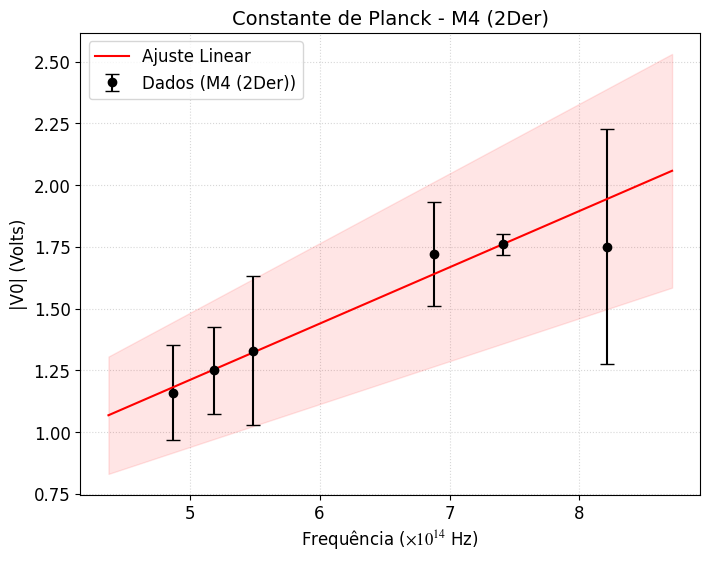

In [28]:
# --- Determinação da Constante de Planck (Usando o Melhor Método Estatisticamente) ---


def plot_planck_determination_final(
    df_results, best_method_col="M4 (2Der)", sigma_col="Sigma_M4"
):
    x_freq, y_v0, y_err = [], [], []
    colors_ordered = [
        "Vermelho",
        "Amarelo",
        "Verde",
        "Azul",
        "Violeta",
        "Ultra-Violeta",
    ]

    for color in colors_ordered:
        if color in df_results.index:
            try:
                f = frequencias[color]
                v = df_results.loc[color, best_method_col]
                sigma = df_results.loc[color, sigma_col]

                if not np.isnan(v):
                    x_freq.append(f)
                    y_v0.append(v)  # Já está em módulo
                    y_err.append(sigma if not np.isnan(sigma) else 0.05)
            except KeyError:
                continue

    x = np.array(x_freq)
    y = np.array(y_v0)
    sigma = np.array(y_err)

    # Regressão Linear Ponderada
    def model(x, a, b):
        return a * x + b

    popt, pcov = curve_fit(model, x, y, sigma=sigma, absolute_sigma=True)
    slope, intercept = popt
    slope_err, intercept_err = np.sqrt(np.diag(pcov))

    # Constantes
    h_meas = slope * 1e-14
    h_err = slope_err * 1e-14
    phi_meas = intercept
    phi_err = intercept_err

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(
        x, y, yerr=sigma, fmt="ko", capsize=5, label=f"Dados ({best_method_col})"
    )

    x_range = np.linspace(min(x) - 0.5, max(x) + 0.5, 100)
    ax.plot(x_range, model(x_range, slope, intercept), "r-", label="Ajuste Linear")
    ax.fill_between(
        x_range,
        model(x_range, slope - slope_err, intercept),
        model(x_range, slope + slope_err, intercept),
        color="red",
        alpha=0.1,
    )

    ax.legend()
    ax.set_xlabel(r"Frequência ($\times 10^{14}$ Hz)", fontsize=12)
    ax.set_ylabel(r"|V0| (Volts)", fontsize=12)
    ax.set_title(f"Constante de Planck - {best_method_col}", fontsize=14)
    ax.grid(True, ls=":", alpha=0.5)

    # Resultados
    print("=" * 40)
    print(f"CONSTANTE DE PLANCK (h)")
    print(f"Valor Medido: {h_meas:.4e} ± {h_err:.1e} eV.s")
    print(f"Teórico:      {h:.4e} eV.s")
    print(f"Erro Relativo: {100*abs(h_meas - h)/h:.2f}%")
    print("-" * 40)
    print(f"FUNÇÃO TRABALHO (Phi)")
    print(f"Média: {phi_meas:.3f} ± {phi_err:.3f} eV")
    print("=" * 40)

    return h_meas, h_err, phi_meas, phi_err


if "df_comp" in globals() and "best_method" in globals():
    # Usar o melhor método determinado estatisticamente
    best_method_name = best_method[0]
    print(f"\n✓ Usando o melhor método: {best_method_name}\n")
    plot_planck_determination_final(df_comp, best_method_col=best_method_name)
elif "df_comp" in globals():
    # Fallback para M4 se análise estatística não foi executada
    print("\n⚠ Análise estatística não encontrada. Usando M4 (2Der) como padrão.\n")
    plot_planck_determination_final(df_comp)
else:
    print("Execute as células anteriores para gerar 'df_comp' e 'best_method'.")